# SaaS Product Analytics & Churn Prediction

## 02 — Product Analytics

### Objective

Analyze SaaS product usage and customer engagement using event-level activity.

This notebook answers:

- How active are customers?
- How does daily, weekly, and monthly activity change over time?
- Which product events are used most frequently?
- How engaged are users with the platform?
- What percentage of monthly users are active on a typical day?
- Which customers demonstrate strong product engagement?
- Which product behaviors may later help explain churn?

### Key Metrics

- DAU — Daily Active Users
- WAU — Weekly Active Users
- MAU — Monthly Active Users
- DAU/MAU Engagement Ratio
- Event Volume
- Events per Active User
- Feature Adoption
- User Engagement Distribution

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Project Configuration

Load the processed events dataset and the analytics outputs generated by the Python pipeline.

In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

ANALYTICS_DIR = (
    PROJECT_ROOT / "data" / "analytics"
)

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction


# Load Events

In [4]:
events_path = (
    PROCESSED_DATA_DIR / "events.csv"
)

if not events_path.exists():
    events_path = (
        PROJECT_ROOT
        / "data"
        / "raw"
        / "events.csv"
    )

events = pd.read_csv(
    events_path
)

print(
    f"Events loaded: {len(events):,}"
)

print(
    f"Columns: {len(events.columns)}"
)

display(events.head())

Events loaded: 1,552,178
Columns: 9


,event_id,user_id,company_id,event_timestamp,event_type,feature,session_id,device,session_duration_minutes
0,E00005929,U001250,C05076,2024-01-05 13:54:32,subscription_started,Billing,S00005646,Desktop,7.22
1,E00000867,U001408,C06792,2024-01-06 13:46:10,login,Authentication,S00000835,Desktop,4.58
2,E00002867,U001387,C04886,2024-01-07 16:04:43,project_created,Project Management,S00002739,Mobile,13.09
3,E00007718,U022162,C01687,2024-01-07 18:56:54,task_completed,Task Management,S00007354,Desktop,9.93
4,E00001173,U025402,C07723,2024-01-08 00:02:10,comment_added,Collaboration,S00001107,Desktop,2.77


In [5]:
print("Event columns:")
print(events.columns.tolist())

Event columns:
['event_id', 'user_id', 'company_id', 'event_timestamp', 'event_type', 'feature', 'session_id', 'device', 'session_duration_minutes']


In [6]:
date_candidates = [
    "event_date",
    "date",
    "timestamp",
    "event_timestamp",
    "created_at",
]

event_date_column = next(
    (
        column
        for column in date_candidates
        if column in events.columns
    ),
    None,
)

if event_date_column is None:
    raise ValueError(
        "Could not identify the event date column."
    )

events[event_date_column] = pd.to_datetime(
    events[event_date_column],
    errors="coerce",
)

events["date"] = (
    events[event_date_column]
    .dt.normalize()
)

print(
    "Event date column:",
    event_date_column,
)

print(
    "Date range:",
    events["date"].min(),
    "to",
    events["date"].max(),
)

Event date column: event_timestamp
Date range: 2024-01-05 00:00:00 to 2026-07-31 00:00:00


# Basic Product Activity

## 2. Overall Product Activity

We first establish the overall scale of product usage.

Important measures include:

- Total events
- Unique active users
- Average events per user
- Average daily event volume

In [7]:
total_events = len(events)

unique_users = (
    events["user_id"].nunique()
    if "user_id" in events.columns
    else np.nan
)

active_days = (
    events["date"].nunique()
)

average_events_per_user = (
    total_events / unique_users
    if unique_users
    else np.nan
)

average_daily_events = (
    total_events / active_days
    if active_days
    else np.nan
)

overview = pd.DataFrame(
    {
        "Metric": [
            "Total Events",
            "Unique Active Users",
            "Active Days",
            "Average Events per User",
            "Average Daily Events",
        ],
        "Value": [
            total_events,
            unique_users,
            active_days,
            average_events_per_user,
            average_daily_events,
        ],
    }
)

display(overview)

,Metric,Value
0,Total Events,"1,552,178.00"
1,Unique Active Users,"30,000.00"
2,Active Days,939.00
3,Average Events per User,51.74
4,Average Daily Events,"1,653.01"


# Daily Active Users

## 3. Daily Active Users — DAU

DAU measures the number of unique users who interacted with the product on each day.

A growing DAU generally indicates increasing product engagement, while declining DAU may signal reduced usage or potential retention issues.

In [8]:
daily_active_users = (
    events.groupby("date")["user_id"]
    .nunique()
    .reset_index(
        name="dau"
    )
)

display(
    daily_active_users.head()
)

,date,dau
0,2024-01-05,1
1,2024-01-06,1
2,2024-01-07,2
3,2024-01-08,4
4,2024-01-09,4


In [9]:
print(
    "Average DAU:",
    f"{daily_active_users['dau'].mean():,.0f}"
)

print(
    "Maximum DAU:",
    f"{daily_active_users['dau'].max():,.0f}"
)

print(
    "Minimum DAU:",
    f"{daily_active_users['dau'].min():,.0f}"
)

Average DAU: 1,388
Maximum DAU: 29,629
Minimum DAU: 1


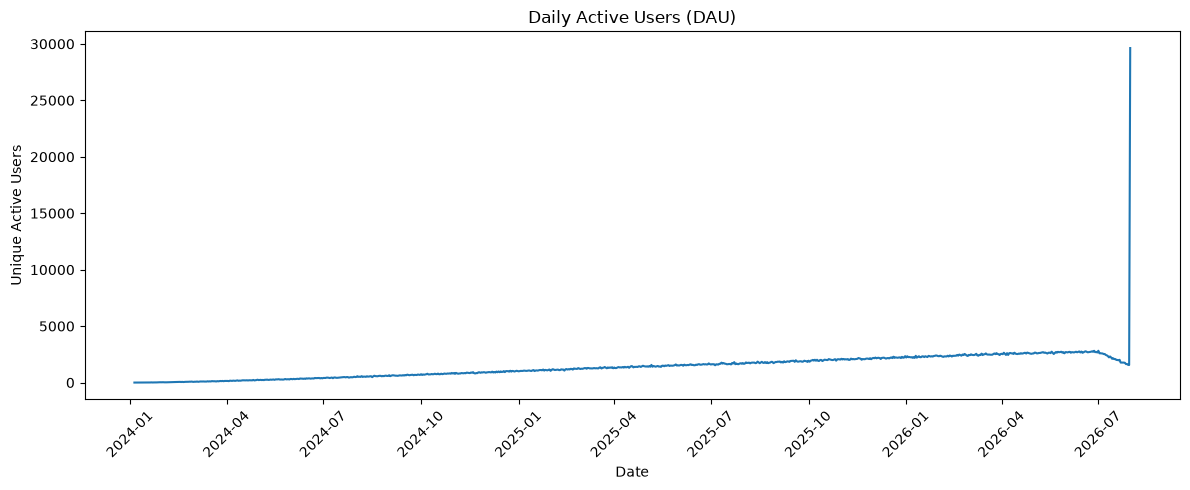

In [10]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    daily_active_users["date"],
    daily_active_users["dau"],
)

plt.title(
    "Daily Active Users (DAU)"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Unique Active Users"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

# Weekly Active Users

## 4. Weekly Active Users — WAU

WAU measures unique users active during each week.

Compared with DAU, WAU provides a broader view of engagement and is less sensitive to daily fluctuations.

In [11]:
weekly_events = events.copy()

weekly_events["week"] = (
    weekly_events["date"]
    .dt.to_period("W")
    .dt.start_time
)

weekly_active_users = (
    weekly_events
    .groupby("week")["user_id"]
    .nunique()
    .reset_index(
        name="wau"
    )
)

display(
    weekly_active_users.head()
)

,week,wau
0,2024-01-01,4
1,2024-01-08,33
2,2024-01-15,56
3,2024-01-22,103
4,2024-01-29,174


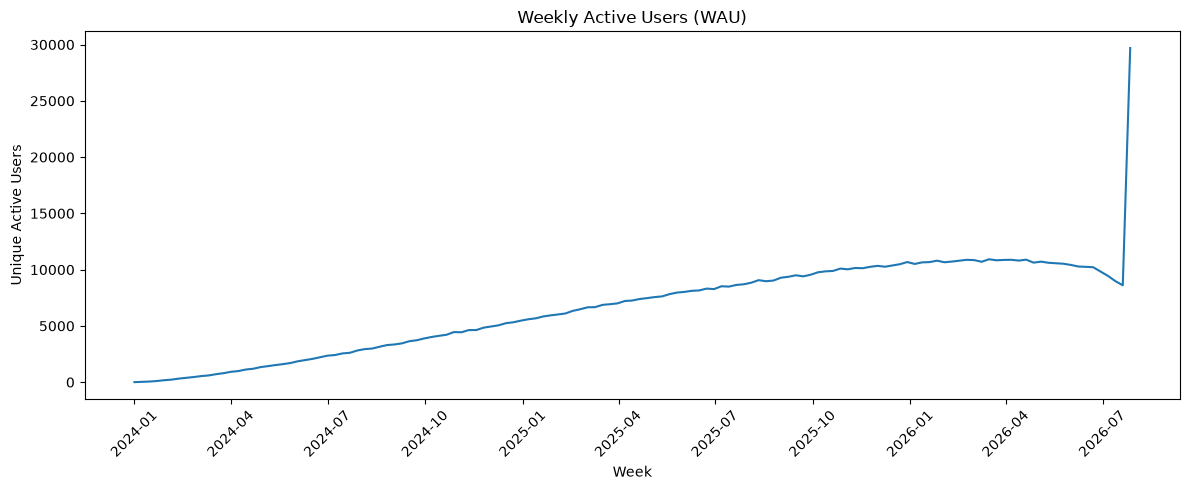

In [12]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    weekly_active_users["week"],
    weekly_active_users["wau"],
)

plt.title(
    "Weekly Active Users (WAU)"
)

plt.xlabel(
    "Week"
)

plt.ylabel(
    "Unique Active Users"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

# Monthly Active Users

## 5. Monthly Active Users — MAU

MAU measures the number of unique users who interacted with the product during each month.

MAU is one of the most important SaaS product-health indicators because it shows the size of the actively engaged customer population.

In [13]:
monthly_events = events.copy()

monthly_events["month"] = (
    monthly_events["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_active_users = (
    monthly_events
    .groupby("month")["user_id"]
    .nunique()
    .reset_index(
        name="mau"
    )
)

display(
    monthly_active_users.head()
)

,month,mau
0,2024-01-01,231
1,2024-02-01,921
2,2024-03-01,1748
3,2024-04-01,2670
4,2024-05-01,3659


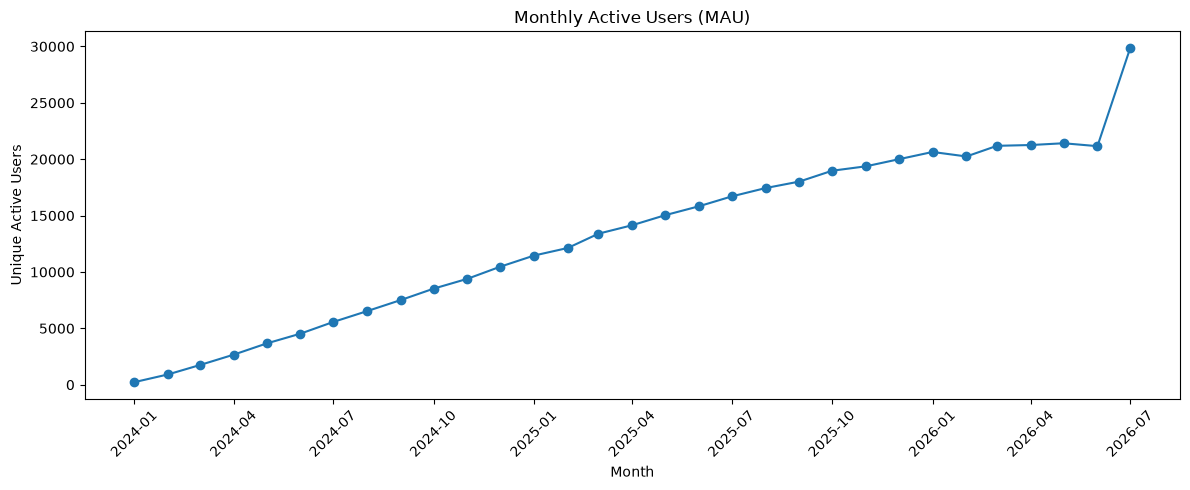

In [14]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    monthly_active_users["month"],
    monthly_active_users["mau"],
    marker="o",
)

plt.title(
    "Monthly Active Users (MAU)"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Unique Active Users"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

# DAU / MAU Engagement

## 6. DAU / MAU Engagement Ratio

The DAU/MAU ratio estimates how frequently monthly active users return to the product.

A higher ratio generally indicates stronger product engagement.

Formula:

DAU / MAU

For monthly reporting, we compare average daily active users with monthly active users.

In [15]:
daily_monthly = events.copy()

daily_monthly["month"] = (
    daily_monthly["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

daily_dau = (
    daily_monthly
    .groupby(
        ["month", "date"]
    )["user_id"]
    .nunique()
    .reset_index(
        name="dau"
    )
)

monthly_mau = (
    daily_monthly
    .groupby("month")["user_id"]
    .nunique()
    .reset_index(
        name="mau"
    )

)

average_dau = (
    daily_dau
    .groupby("month")["dau"]
    .mean()
    .reset_index(
        name="average_dau"
    )
)

engagement = average_dau.merge(
    monthly_mau,
    on="month",
    how="left",
)

engagement[
    "dau_mau_ratio"
] = (
    engagement["average_dau"]
    / engagement["mau"]
)

display(engagement)

,month,average_dau,mau,dau_mau_ratio
0,2024-01-01,10.89,231,0.05
1,2024-02-01,50.52,921,0.05
2,2024-03-01,106.94,1748,0.06
3,2024-04-01,184.47,2670,0.07
4,2024-05-01,264.03,3659,0.07
5,2024-06-01,356.00,4528,0.08
6,2024-07-01,450.00,5563,0.08
7,2024-08-01,554.97,6525,0.09
8,2024-09-01,650.43,7512,0.09
9,2024-10-01,759.65,8521,0.09


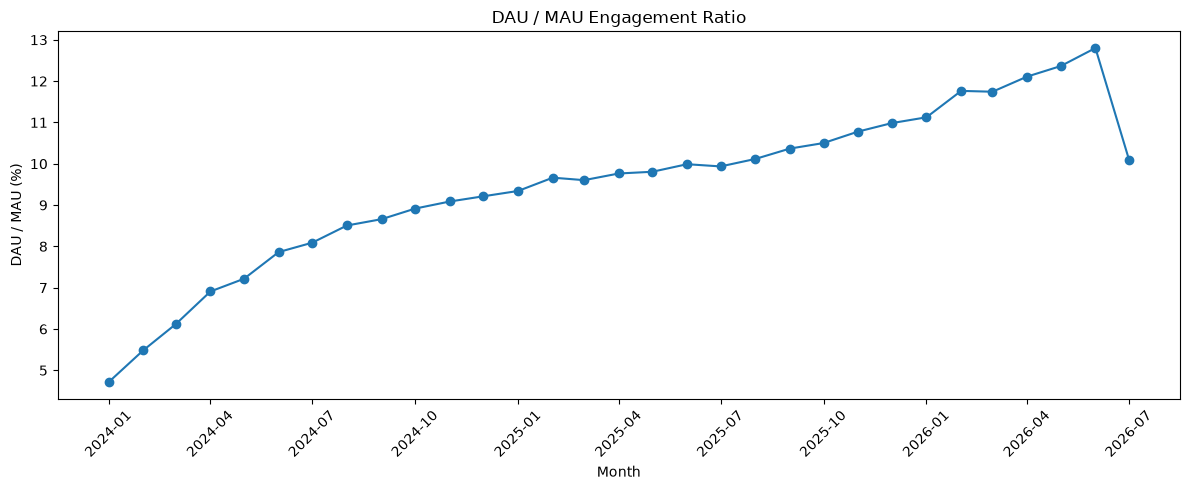

In [16]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    engagement["month"],
    engagement["dau_mau_ratio"] * 100,
    marker="o",
)

plt.title(
    "DAU / MAU Engagement Ratio"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "DAU / MAU (%)"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

# Event Analysis

## 7. Product Event Analysis

Understanding which actions users perform most frequently helps identify the core behaviors driving product engagement.

We will analyze:

- Event volume
- Event frequency
- Unique users per event
- Average events per participating user

In [17]:
if "event_type" not in events.columns:
    raise ValueError(
        "event_type column was not found."
    )

event_summary = (
    events
    .groupby("event_type")
    .agg(
        event_count=(
            "event_type",
            "size"
        ),
        unique_users=(
            "user_id",
            "nunique"
        ),
    )
    .reset_index()
)

event_summary[
    "events_per_user"
] = (
    event_summary["event_count"]
    / event_summary["unique_users"]
)

event_summary = (
    event_summary
    .sort_values(
        "event_count",
        ascending=False,
    )
)

display(event_summary)

,event_type,event_count,unique_users,events_per_user
2,login,384451,29998,12.82
11,task_completed,299544,29991,9.99
12,task_created,296439,29984,9.89
5,project_created,162088,29743,5.45
0,comment_added,113206,28986,3.91
1,file_uploaded,85911,27866,3.08
13,team_member_invited,55495,24787,2.24
8,subscription_started,41401,20547,2.01
6,report_generated,36023,20541,1.75
10,support_viewed,27585,17891,1.54


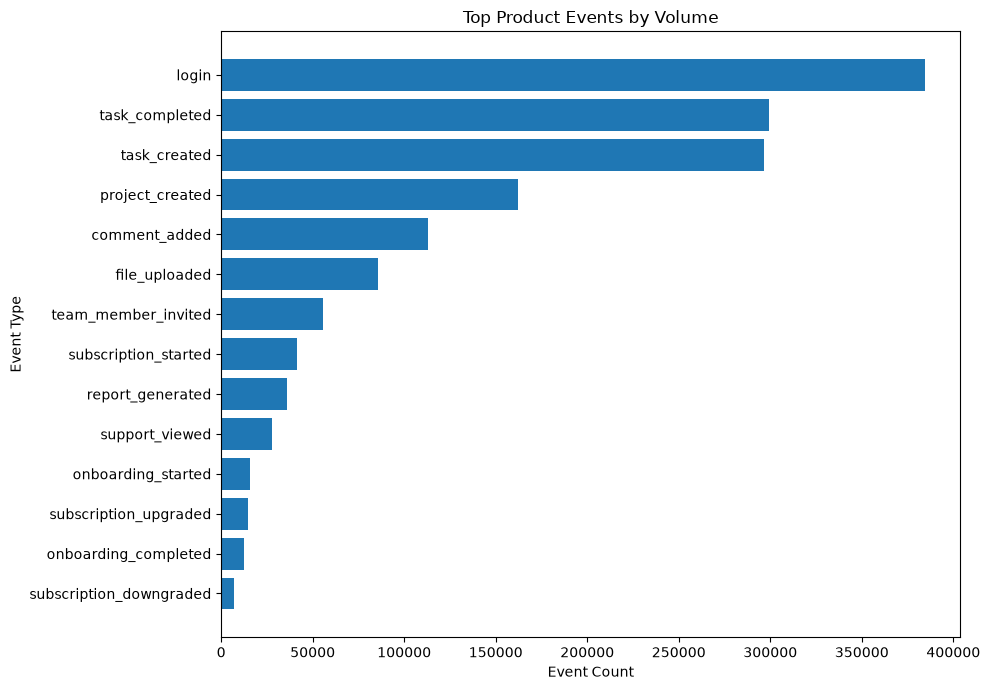

In [18]:
top_events = (
    event_summary
    .head(15)
    .sort_values(
        "event_count"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_events["event_type"],
    top_events["event_count"],
)

plt.title(
    "Top Product Events by Volume"
)

plt.xlabel(
    "Event Count"
)

plt.ylabel(
    "Event Type"
)

plt.tight_layout()

plt.show()

# Event Adoption

## 8. Feature / Event Adoption

Event volume alone does not tell us how widely a feature is adopted.

A feature may generate many events because a small group of users uses it repeatedly.

Therefore we also measure:

> Percentage of active users who performed each event.

In [19]:
total_active_users = (
    events["user_id"].nunique()
)

event_adoption = (
    events
    .groupby("event_type")["user_id"]
    .nunique()
    .reset_index(
        name="unique_users"
    )
)

event_adoption[
    "adoption_pct"
] = (
    event_adoption["unique_users"]
    / total_active_users
    * 100
)

event_adoption = (
    event_adoption
    .sort_values(
        "adoption_pct",
        ascending=False,
    )
)

display(event_adoption)

,event_type,unique_users,adoption_pct
2,login,29998,99.99
11,task_completed,29991,99.97
12,task_created,29984,99.95
5,project_created,29743,99.14
0,comment_added,28986,96.62
1,file_uploaded,27866,92.89
13,team_member_invited,24787,82.62
8,subscription_started,20547,68.49
6,report_generated,20541,68.47
10,support_viewed,17891,59.64


# User Engagement

## 9. User Engagement Distribution

We now move from aggregate product activity to customer-level behavior.

For each user we calculate:

- Total events
- Active days
- Active weeks
- Active months
- Events per active day

In [21]:
events["month"] = events["date"].dt.to_period("M")

user_engagement = (
    events
    .groupby("user_id")
    .agg(
        total_events=("user_id", "size"),
        active_days=("date", "nunique"),
        active_months=("month", "nunique"),
    )
    .reset_index()
)

user_engagement["events_per_active_day"] = (
    user_engagement["total_events"]
    / user_engagement["active_days"]
)

display(user_engagement.head())

,user_id,total_events,active_days,active_months,events_per_active_day
0,U000001,44,42,18,1.05
1,U000002,36,34,18,1.06
2,U000003,51,44,9,1.16
3,U000004,42,37,17,1.14
4,U000005,70,60,11,1.17


In [22]:
engagement_summary = (
    user_engagement[
        [
            "total_events",
            "active_days",
            "active_months",
            "events_per_active_day",
        ]
    ]
    .describe()
    .T
)

display(
    engagement_summary
)

,count,mean,std,min,25%,50%,75%,max
total_events,"30,000.00",51.74,13.51,14.00,42.00,51.00,61.00,106.00
active_days,"30,000.00",43.44,11.38,12.00,35.00,43.00,51.00,89.00
active_months,"30,000.00",13.67,6.41,1.00,8.00,14.00,19.00,29.00
events_per_active_day,"30,000.00",1.20,0.18,1.00,1.10,1.16,1.23,3.14


# Engagement Segments

## 10. Customer Engagement Segmentation

For exploratory analysis, customers are grouped into four engagement levels based on total product activity.

These thresholds are analytical segments rather than machine-learning labels.

In [23]:
def engagement_segment(events_count):

    if events_count < 10:
        return "Low"

    elif events_count < 50:
        return "Moderate"

    elif events_count < 100:
        return "High"

    return "Very High"


user_engagement[
    "engagement_segment"
] = (
    user_engagement[
        "total_events"
    ]
    .apply(
        engagement_segment
    )
)

segment_summary = (
    user_engagement[
        "engagement_segment"
    ]
    .value_counts()
    .rename_axis(
        "engagement_segment"
    )
    .reset_index(
        name="users"
    )
)

segment_summary[
    "percentage"
] = (
    segment_summary["users"]
    / len(user_engagement)
    * 100
)

display(
    segment_summary
)

,engagement_segment,users,percentage
0,High,16020,53.40
1,Moderate,13966,46.55
2,Very High,14,0.05


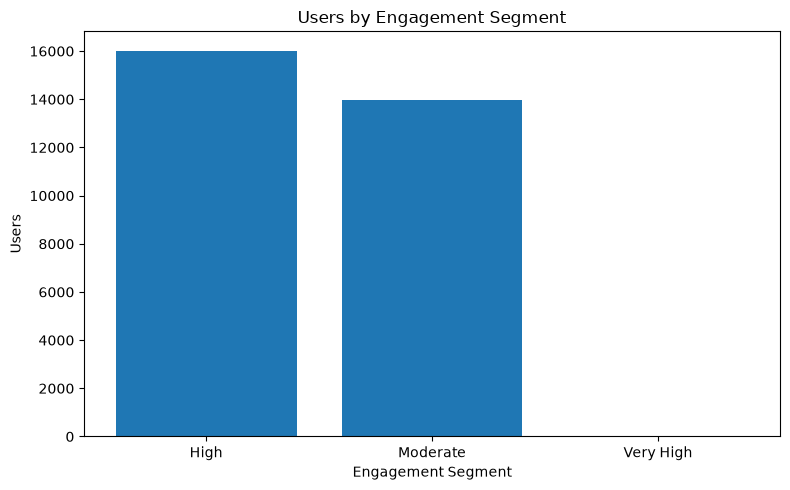

In [24]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    segment_summary[
        "engagement_segment"
    ],
    segment_summary[
        "users"
    ],
)

plt.title(
    "Users by Engagement Segment"
)

plt.xlabel(
    "Engagement Segment"
)

plt.ylabel(
    "Users"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

# Monthly Event Volume

## 11. Monthly Product Activity

Monthly event volume provides another perspective on product adoption and usage trends.

An increase in events may indicate:

- More customers
- More frequent usage
- Greater feature adoption
- Increased product dependency

In [25]:
monthly_event_volume = (
    events
    .groupby("month")
    .size()
    .reset_index(
        name="event_count"
    )
)

display(
    monthly_event_volume
)

,month,event_count
0,2024-01,296
1,2024-02,1502
2,2024-03,3402
3,2024-04,5698
4,2024-05,8452
5,2024-06,11121
6,2024-07,14554
7,2024-08,17950
8,2024-09,20401
9,2024-10,24655


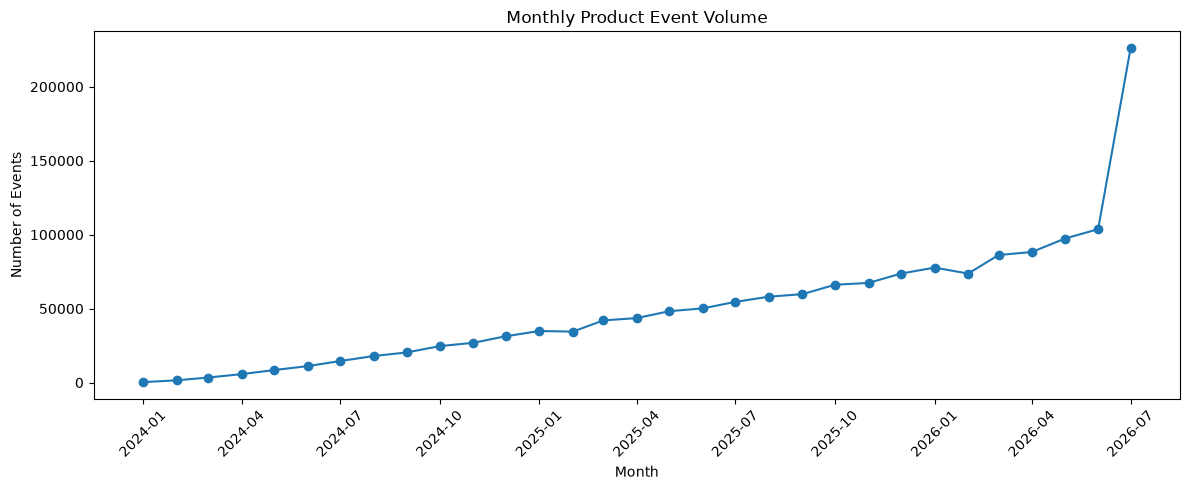

In [27]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    monthly_event_volume["month"].dt.to_timestamp(),
    monthly_event_volume["event_count"],
    marker="o",
)

plt.title(
    "Monthly Product Event Volume"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Number of Events"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

# Product Metrics Output Comparison

## 12. Compare With Python Analytics Pipeline

The `product_metrics.py` script independently generates production-style product metrics.

We compare the notebook calculations with those outputs where available.

This provides a basic validation that the analytical notebook and reusable Python pipeline are aligned.

In [28]:
product_metrics_path = (
    ANALYTICS_DIR
    / "daily_product_metrics.csv"
)

if product_metrics_path.exists():

    production_metrics = pd.read_csv(
        product_metrics_path
    )

    print(
        "Production product metrics found:"
    )

    display(
        production_metrics.head()
    )

else:

    print(
        "daily_product_metrics.csv was not found."
    )

    print(
        "Notebook calculations will be used."
    )

Production product metrics found:


,date,dau,wau,mau,total_events,sessions,avg_session_duration_minutes,total_session_duration_minutes,stickiness_dau_mau,events_per_active_user,sessions_per_active_user
0,2024-01-05,1,1,1,1,1,7.22,7.22,100.00,1.00,1.00
1,2024-01-06,1,2,2,1,1,4.58,4.58,50.00,1.00,1.00
2,2024-01-07,2,4,4,2,2,11.51,23.02,50.00,1.00,1.00
3,2024-01-08,4,8,8,5,4,3.75,18.73,50.00,1.25,1.00
4,2024-01-09,4,11,11,4,4,5.03,20.13,36.36,1.00,1.00


# Product Analytics Summary

## 13. Product Analytics Summary

### Product Activity

The event dataset provides a detailed view of customer interaction with the SaaS platform.

### Active Users

DAU, WAU, and MAU provide complementary views of product engagement:

- DAU measures daily activity.
- WAU measures weekly reach.
- MAU measures the broader active customer base.

### Engagement

The DAU/MAU ratio provides an indication of how frequently monthly active customers return to the product.

### Feature Adoption

Event-level adoption identifies the product actions used by the largest proportion of customers.

### Customer Engagement

Customer-level event activity allows users to be segmented according to their level of product engagement.

### Churn Connection

These engagement metrics will later be connected with churn analysis to investigate whether lower product activity is associated with increased churn risk.

# Key Questions for Next Analysis

## 14. Business Questions Generated

The product analytics stage raises several important business questions:

1. Which product features are most widely adopted?

2. Which features are heavily used but concentrated among a small number of customers?

3. Are highly engaged users less likely to churn?

4. Does declining activity precede customer churn?

5. Which user behaviors are associated with long-term retention?

6. Are customers with low engagement generating a disproportionate amount of support activity?

7. Which product actions should be considered in the churn prediction model?

These questions will be explored in the subsequent funnel, retention, and churn analyses.

# Conclusion

## 15. Conclusion

The product analytics analysis establishes the behavioral foundation of the SaaS project.

The analysis covers:

- DAU
- WAU
- MAU
- DAU/MAU engagement
- Event volume
- Feature adoption
- Customer engagement
- Engagement segmentation
- Monthly product activity

The next stage is **Funnel Analysis**, where we move from general product activity to the customer journey and identify where users progress or drop off.

---

**Next Notebook:** `03_Funnel_Analysis.ipynb`